<a href="https://colab.research.google.com/github/sitisaibah32/analisis-marketplace-rantai-markov/blob/main/UAS_PROSTOK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA AWAL
   Marketplace  Jumlah Pengguna
0       Shopee               19
1    Tokopedia               55
2       Lazada                4
3  TikTok Shop                3
4       Blibli                5


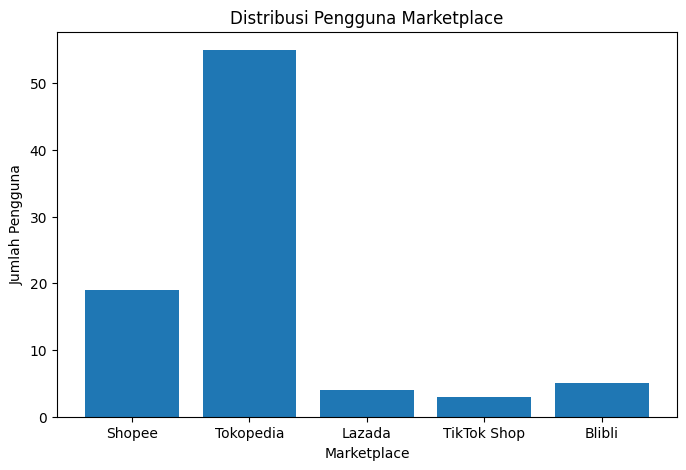


Distribusi Awal
[0.2209 0.6395 0.0465 0.0349 0.0581]

Matriks Probabilitas Transisi
             Shopee  Tokopedia  Lazada  TikTok Shop  Blibli
Shopee         0.53       0.36    0.05         0.00    0.05
Tokopedia      0.24       0.65    0.00         0.00    0.11
Lazada         0.50       0.00    0.25         0.00    0.25
TikTok Shop    0.00       0.67    0.00         0.33    0.00
Blibli         0.20       0.60    0.00         0.00    0.20

PERKEMBANGAN MARKET SHARE

Periode 1
[0.3055 0.5535 0.0227 0.0115 0.1047]

Periode 2
[0.327  0.5402 0.0209 0.0038 0.1028]

Periode 3
[0.334  0.5331 0.0216 0.0013 0.1016]

Periode 4
[3.361e-01 5.285e-01 2.210e-02 4.000e-04 1.010e-01]

Periode 5
[3.362e-01 5.254e-01 2.230e-02 1.000e-04 1.007e-01]

Periode 6
[0.3356 0.5231 0.0224 0.     0.1003]

Periode 7
[0.3347 0.521  0.0224 0.     0.1   ]

Periode 8
[0.3336 0.5191 0.0223 0.     0.0996]

Periode 9
[0.3325 0.5173 0.0223 0.     0.0993]

Periode 10
[0.3314 0.5155 0.0222 0.     0.099 ]


STEADY STATE
[0

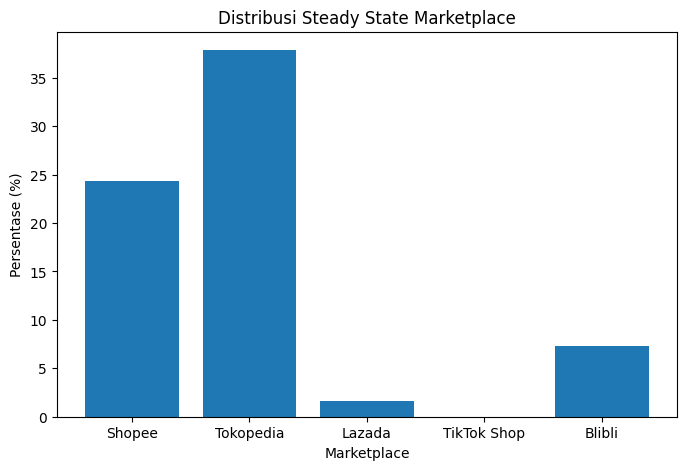


Marketplace Dominan Jangka Panjang
Marketplace : Tokopedia
Probabilitas : 37.86 %

KESIMPULAN
Berdasarkan analisis Rantai Markov, marketplace Tokopedia memiliki probabilitas steady state terbesar sebesar 37.86% sehingga diprediksi menjadi marketplace yang paling dominan dalam jangka panjang.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# DATA AWAL RESPONDEN

marketplace = [
    "Shopee",
    "Tokopedia",
    "Lazada",
    "TikTok Shop",
    "Blibli"
]

jumlah_pengguna = [19, 55, 4, 3, 5]

df = pd.DataFrame({
    "Marketplace": marketplace,
    "Jumlah Pengguna": jumlah_pengguna
})

print("DATA AWAL")
print(df)

# VISUALISASI DATA AWAL

plt.figure(figsize=(8,5))
plt.bar(df["Marketplace"], df["Jumlah Pengguna"])
plt.title("Distribusi Pengguna Marketplace")
plt.xlabel("Marketplace")
plt.ylabel("Jumlah Pengguna")
plt.show()


# VEKTOR PROBABILITAS AWAL

pi0 = np.array([19,55,4,3,5])

pi0 = pi0 / pi0.sum()

print("\nDistribusi Awal")
print(np.round(pi0,4))

# MATRIKS PROBABILITAS TRANSISI

P = np.array([
    [0.53, 0.36, 0.05, 0.00, 0.05],
    [0.24, 0.65, 0.00, 0.00, 0.11],
    [0.50, 0.00, 0.25, 0.00, 0.25],
    [0.00, 0.67, 0.00, 0.33, 0.00],
    [0.20, 0.60, 0.00, 0.00, 0.20]
])

print("\nMatriks Probabilitas Transisi")
print(pd.DataFrame(
    P,
    index=marketplace,
    columns=marketplace
))

# MARKET SHARE TIAP PERIODE


print("\nPERKEMBANGAN MARKET SHARE\n")

state = pi0.copy()

for i in range(1,11):

    state = state @ P

    print("Periode", i)
    print(np.round(state,4))
    print()


# STEADY STATE


state = pi0.copy()

for i in range(100):

    state_baru = state @ P

    if np.allclose(state, state_baru, atol=1e-10):
        break

    state = state_baru

steady_state = state

print("\nSTEADY STATE")
print(np.round(steady_state,4))


# TABEL HASIL STEADY STATE

hasil = pd.DataFrame({
    "Marketplace": marketplace,
    "Steady State": steady_state,
    "Persentase (%)": steady_state*100
})

print("\nHASIL STEADY STATE")
print(hasil)


# GRAFIK STEADY STATE

plt.figure(figsize=(8,5))
plt.bar(
    hasil["Marketplace"],
    hasil["Persentase (%)"]
)

plt.title("Distribusi Steady State Marketplace")
plt.xlabel("Marketplace")
plt.ylabel("Persentase (%)")
plt.show()


# MARKETPLACE DOMINAN

idx = np.argmax(steady_state)

print("\nMarketplace Dominan Jangka Panjang")
print("Marketplace :", marketplace[idx])
print("Probabilitas :", round(steady_state[idx]*100,2), "%")

# KESIMPULAN

print("\nKESIMPULAN")

print(
    "Berdasarkan analisis Rantai Markov, marketplace "
    + marketplace[idx]
    + " memiliki probabilitas steady state terbesar sebesar "
    + str(round(steady_state[idx]*100,2))
    + "% sehingga diprediksi menjadi marketplace yang paling dominan dalam jangka panjang."
)